In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

In [3]:
inicio = time.perf_counter()

In [4]:
# Reprodutibilidade
SEED = 123

In [5]:
df = pd.read_csv("final_dataset.csv")

In [6]:
# Agrupa chuva intensa na classe Rain
df["precipitation"] = df["precipitation"].replace("Extreme rain", "Rain")

X = df.drop(columns=["precipitation"])
y = df["precipitation"]

# Ordem usada na matriz de confusão:
# cm[0, 0] = Rain predito como Rain
# cm[0, 1] = Rain predito como No rain
# cm[1, 0] = No rain predito como Rain
# cm[1, 1] = No rain predito como No rain
labels = ["Rain", "No rain"]

y.value_counts()

precipitation
No rain    431380
Rain        37431
Name: count, dtype: int64

In [7]:
def criar_modelo_svm(seed=SEED):
    """Cria o pipeline do SVM linear.

    O undersampling fica dentro da validação cruzada, evitando balancear
    antes da separação treino/teste de cada fold.

    Observação:
    - Foi usado LinearSVC porque é mais viável para base grande.
    - SVC(kernel='rbf') pode ficar muito lento nesse volume de dados.
    """
    return Pipeline(steps=[
        ("undersampling", RandomUnderSampler(random_state=seed)),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ("scaler", StandardScaler(with_mean=False)),
        ("modelo", LinearSVC(
            C=1.0,
            class_weight=None,
            random_state=seed,
            max_iter=10000,
            dual=False
        ))
    ])


def metricas_da_matriz(cm):
    """Calcula métricas considerando a ordem: labels = ['Rain', 'No rain']."""
    VP = cm[0, 0]
    FN = cm[0, 1]
    FP = cm[1, 0]
    VN = cm[1, 1]

    acuracia = (VP + VN) / cm.sum()
    sensibilidade = VP / (VP + FN) if (VP + FN) > 0 else np.nan
    especificidade = VN / (VN + FP) if (VN + FP) > 0 else np.nan

    return {
        "Acurácia": acuracia,
        "Sensibilidade": sensibilidade,
        "Especificidade": especificidade
    }


def score_classe_rain(modelo_svm, X_teste):
    """Retorna o score do SVM para a classe Rain.

    O LinearSVC não possui predict_proba por padrão.
    Para construir a curva ROC, usamos decision_function.
    """
    svm = modelo_svm.named_steps["modelo"]
    scores = modelo_svm.decision_function(X_teste)

    # Em problema binário, decision_function retorna score positivo para classes_[1].
    # Se Rain não for classes_[1], invertemos o sinal.
    if len(svm.classes_) == 2:
        if svm.classes_[1] == "Rain":
            return scores
        else:
            return -scores

    raise ValueError("Este código foi preparado para classificação binária: Rain vs No rain.")

In [8]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cm_total = np.zeros((2, 2), dtype=int)
matrizes_folds = {}
resultados = []

y_test_total = []
y_score_total = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    print(f"Rodando fold {fold}...")

    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    modelo_svm = criar_modelo_svm()
    modelo_svm.fit(X_train_fold, y_train_fold)

    y_pred_fold = modelo_svm.predict(X_test_fold)

    cm_fold = confusion_matrix(
        y_test_fold,
        y_pred_fold,
        labels=labels
    )

    cm_total += cm_fold
    matrizes_folds[f"Fold {fold}"] = cm_fold

    # Score do SVM para a classe Rain.
    # Para SVM, usamos decision_function, não predict_proba.
    y_score_fold = score_classe_rain(modelo_svm, X_test_fold)
    y_test_bin_fold = (y_test_fold == "Rain").astype(int)

    metricas = metricas_da_matriz(cm_fold)
    metricas["AUC"] = roc_auc_score(y_test_bin_fold, y_score_fold)

    for metrica, valor in metricas.items():
        resultados.append({
            "Fold": fold,
            "Métrica": metrica,
            "Valor": valor
        })

    y_test_total.extend(y_test_bin_fold.to_numpy())
    y_score_total.extend(y_score_fold)

Rodando fold 1...
Rodando fold 2...
Rodando fold 3...
Rodando fold 4...
Rodando fold 5...


In [9]:
matriz_confusao_total = pd.DataFrame(
    cm_total,
    index=["Real Rain", "Real No rain"],
    columns=["Predito Rain", "Predito No rain"]
)

resultados_cv = pd.DataFrame(resultados)

tabela_cv = resultados_cv.pivot(
    index="Métrica",
    columns="Fold",
    values="Valor"
)

tabela_cv.columns = [f"Fold {col}" for col in tabela_cv.columns]
tabela_cv["Média"] = tabela_cv.mean(axis=1)
tabela_cv["DP"] = tabela_cv.std(axis=1)

display(matriz_confusao_total)
display(tabela_cv)

,Predito Rain,Predito No rain
Real Rain,28900,8531
Real No rain,147837,283543


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Média,DP
Métrica,,,,,,,
AUC,0.788162,0.788290,0.788816,0.787226,0.789892,0.788477,0.000874
Acurácia,0.664836,0.669493,0.666624,0.665195,0.666144,0.666458,0.001647
Especificidade,0.655397,0.660717,0.657367,0.655791,0.657193,0.657293,0.001876
Sensibilidade,0.773608,0.770639,0.773310,0.773577,0.769303,0.772087,0.001782


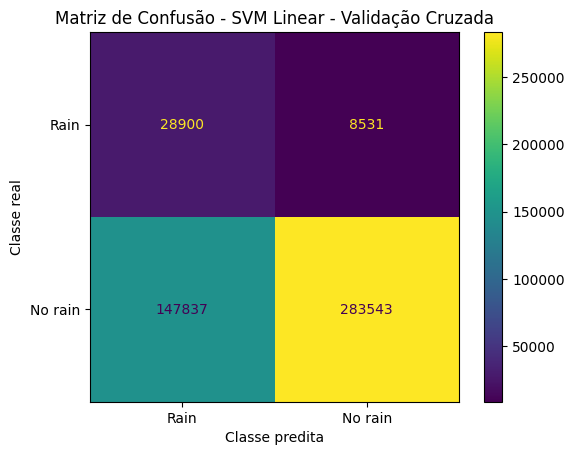

In [10]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_total.astype(int),
    display_labels=labels
).plot(values_format="d")

plt.title("Matriz de Confusão - SVM Linear - Validação Cruzada")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")

plt.savefig("matriz_confusao_svm_linear.png", dpi=300, bbox_inches="tight")

plt.show()

AUC geral: 0.7884691311698877


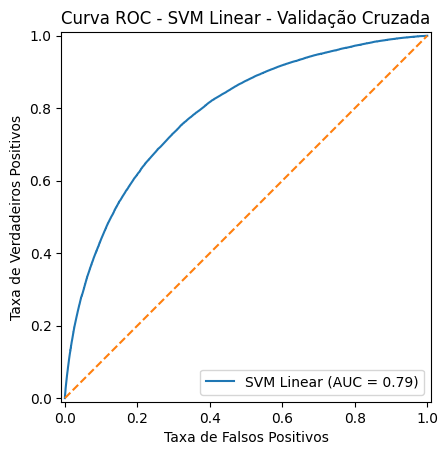

In [11]:
y_test_total = np.array(y_test_total)
y_score_total = np.array(y_score_total)

fpr, tpr, thresholds = roc_curve(y_test_total, y_score_total)
auc = roc_auc_score(y_test_total, y_score_total)

print("AUC geral:", auc)

RocCurveDisplay(
    fpr=fpr,
    tpr=tpr,
    roc_auc=auc,
    estimator_name="SVM Linear"
).plot()

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - SVM Linear - Validação Cruzada")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")

plt.savefig("curva_roc_svm_linear.png", dpi=300, bbox_inches="tight")

plt.show()

In [15]:
fim = time.perf_counter()

tempo_total = fim - inicio

horas = int(tempo_total // 3600)
minutos = int((tempo_total % 3600) // 60)
segundos = tempo_total % 60

print(f"Tempo total do experimento: {horas}h {minutos}min {segundos:.2f}s")

Tempo total do experimento: 0h 0min 11.86s
